## C3DIR Outputs:

3D Voxel: lat x lon x alt

Cloud Properties:

| C3DIR output | What it represents | Units |
|---|---|---|
| **Hydrometeor occurrence** | Probability/presence of any cloud/precipitating hydrometeor | **Unitless probability / binary mask** |
| **Ice occurrence** | Presence/probability of ice cloud | **Unitless probability / binary mask** |
| **Liquid occurrence** | Presence/probability of liquid cloud | **Unitless probability / binary mask** |
| **Rain occurrence** | Presence/probability of rain | **Unitless probability / binary mask** |
| **IWC – Ice Water Content** | Mass of ice per volume of air | **g m⁻³** |
| **LWC – Liquid Water Content** | Mass of cloud liquid water per volume of air | **g m⁻³** |
| **RWC – Rain Water Content** | Mass of rain water per volume of air | **g m⁻³** |
| **Effective radius** | How large the particles are | **µm** |

## ERA5 Outputs:

https://cds.climate.copernicus.eu/requests?tab=all

3D : lat x lon x pressure level (hPa)

| ERA5 output | Variable | What it represents | Units | Closest C3DIR feature |
|---|---|---|---|---|
| **Divergence** | `d` | Horizontal spreading or convergence of the wind field | **s⁻¹** | — |
| **Fraction of cloud cover** | `cc` | Fraction of the atmospheric grid box covered by cloud | **0–1, unitless** | **Hydrometeor occurrence** *(rough proxy only; not equivalent)* |
| **Geopotential** | `z` | Gravitational potential energy per unit mass; can be converted to geopotential height | **m² s⁻²** | **3D altitude coordinate** *(used to convert pressure levels toward altitude)* |
| **Ozone mass mixing ratio** | `o3` | Mass of ozone per unit mass of moist air | **kg kg⁻¹** | — |
| **Potential vorticity** | `pv` | Atmospheric rotation combined with vertical stability | **K m² kg⁻¹ s⁻¹** | — |
| **Relative humidity** | `r` | Water vapor relative to saturation at the given temperature | **%** | — |
| **Specific cloud ice water content** | `ciwc` | Mass of cloud ice per unit mass of moist air | **kg kg⁻¹** | **Ice occurrence**, **IWC** |
| **Specific cloud liquid water content** | `clwc` | Mass of cloud liquid water per unit mass of moist air | **kg kg⁻¹** | **Liquid occurrence**, **LWC** |
| **Specific humidity** | `q` | Mass of water vapor per unit mass of moist air | **kg kg⁻¹** | — *(used in air-density conversion)* |
| **Specific rain water content** | `crwc` | Mass of rain water per unit mass of moist air | **kg kg⁻¹** | **Rain occurrence**, **RWC** |
| **Specific snow water content** | `cswc` | Mass of snow/frozen precipitation per unit mass of moist air | **kg kg⁻¹** | **Hydrometeor occurrence** |
| **Temperature** | `t` | Atmospheric air temperature | **K** | — *(used in air-density conversion)* |
| **U-component of wind** | `u` | East-west component of wind velocity | **m s⁻¹** | — |
| **V-component of wind** | `v` | North-south component of wind velocity | **m s⁻¹** | — |
| **Vertical velocity** | `w` | Vertical atmospheric motion expressed as pressure change | **Pa s⁻¹** | — |
| **Vorticity (relative)** | `vo` | Local rotation of the horizontal wind field | **s⁻¹** | — |

In [21]:
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

grib_path = Path("../data/era5/boston_subset/era5_20260601_20260603_N45.5_W74_S39.5_E68.grib")

ds = xr.open_dataset(grib_path, engine="cfgrib", backend_kwargs={"indexpath": ""})
ds

<xarray.Dataset> Size: 22MB
Dimensions:        (time: 72, isobaricInhPa: 15, latitude: 25, longitude: 25)
Coordinates:
  * time           (time) datetime64[ns] 576B 2026-06-01 ... 2026-06-03T23:00:00
    valid_time     (time) datetime64[ns] 576B ...
  * isobaricInhPa  (isobaricInhPa) float64 120B 1e+03 950.0 900.0 ... 100.0 50.0
  * latitude       (latitude) float64 200B 45.5 45.25 45.0 ... 40.0 39.75 39.5
  * longitude      (longitude) float64 200B -74.0 -73.75 -73.5 ... -68.25 -68.0
    number         int64 8B ...
    step           timedelta64[ns] 8B ...
Data variables:
    cc             (time, isobaricInhPa, latitude, longitude) float32 3MB ...
    z              (time, isobaricInhPa, latitude, longitude) float32 3MB ...
    ciwc           (time, isobaricInhPa, latitude, longitude) float32 3MB ...
    clwc           (time, isobaricInhPa, latitude, longitude) float32 3MB ...
    crwc           (time, isobaricInhPa, latitude, longitude) float32 3MB ...
    cswc           (time, isobaricInhPa, latitude, longitude) float32 3MB ...
    q              (time, isobaricInhPa, latitude, longitude) float32 3MB ...
    t              (time, isobaricInhPa, latitude, longitude) float32 3MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-10-07T18:06 GRIB to CDM+CF via cfgrib-0.9.1...

In [11]:
import numpy as np
import metpy.calc as mpcalc
from metpy.interpolate import interpolate_1d
from metpy.units import units

# constants
G0, RD = 9.80665, 287.05          # gravity (m s-2), dry-air gas constant (J kg-1 K-1)
THRESH = 1e-5                     # C3DIR occurrence threshold (g m-3), the paper uses 1e-5 g m-3
ALT = np.arange(80) * 0.25        # C3DIR vertical levels grid: 80 bins, 0.25 km, centers 0..19.75 km (these fields are averaged to a vertical resolution of 0.25 km)
ALT_M = ALT * 1000

def era5_to_c3dir(ds):
    ds = ds.rename(isobaricInhPa="plev")
    dims = ds.t.dims # (time, plev, lat, lon)

    #* Air density (kg m-3)
    # q -> mixing ratio, then density with virtual temperature (unit-checked by Pint).
    mr = mpcalc.mixing_ratio_from_specific_humidity(ds.q.values * units("kg/kg")) # get the mixing ratio
    p = ds.plev.values[None, :, None, None] * units.hPa
    rho = xr.DataArray(mpcalc.density(p, ds.t.values * units.K, mr).to("kg/m^3").magnitude,
                       coords=ds.t.coords, dims=dims)

    #* Convert mixing ratio (kg/kg) -> water content (g m-3)
    gm3 = lambda x: (x * rho * 1000).clip(min=0)
    water = {
        "IWC": gm3(ds.ciwc + ds.cswc),    # ice = cloud ice + snow
        "LWC": gm3(ds.clwc),              # cloud liquid
        "RWC": gm3(ds.crwc),              # rain
    }

    #* Convert geopotential -> height (m)
    h = (ds.z / G0).transpose(*dims).values

    #* Interpolate pressure levels onto C3DIR altitude grid  [MetPy]
    # Heights differ per column, so h is passed as xp. Bins outside the column's range -> NaN.
    ax = dims.index("plev")
    out = xr.Dataset()
    for k, v in water.items():
        res = interpolate_1d(ALT_M, h, v.transpose(*dims).values, axis=ax)
        out[k] = (("time", "alt", "latitude", "longitude"), np.moveaxis(np.asarray(res), ax, 1))
        
    out = out.assign_coords(time=ds.time, alt=ALT, latitude=ds.latitude, longitude=ds.longitude)
    out = out.clip(min=0) # remove interpolation undershoot

    #* Occurrence masks
    valid = out.IWC.notnull()
    for k, n in [("IWC", "ice"), ("LWC", "liquid"), ("RWC", "rain")]:
        out[f"{n}_occ"] = ((out[k] > THRESH) & valid).astype("uint8")
        
    out["hydrometeor_occ"] = out[["ice_occ", "liquid_occ", "rain_occ"]].to_array().max("variable")

    # metadata
    for k in water: out[k].attrs = {"units": "g m-3"}
    out.alt.attrs = {"units": "km"}
    return out

In [12]:
c3 = era5_to_c3dir(ds)
c3

/var/folders/v8/5vdpb7f91c7635my1d8_r3h00000gn/T/ipykernel_50144/3044289546.py:39: UserWarning: Interpolation point out of data bounds encountered
  res = interpolate_1d(ALT_M, h, v.transpose(*dims).values, axis=ax)


<xarray.Dataset> Size: 101MB
Dimensions:          (time: 72, alt: 80, latitude: 25, longitude: 25)
Coordinates:
  * time             (time) datetime64[ns] 576B 2026-06-01 ... 2026-06-03T23:...
    valid_time       (time) datetime64[ns] 576B ...
  * alt              (alt) float64 640B 0.0 0.25 0.5 0.75 ... 19.25 19.5 19.75
  * latitude         (latitude) float64 200B 45.5 45.25 45.0 ... 40.0 39.75 39.5
  * longitude        (longitude) float64 200B -74.0 -73.75 ... -68.25 -68.0
    number           int64 8B 0
    step             timedelta64[ns] 8B 00:00:00
Data variables:
    IWC              (time, alt, latitude, longitude) float64 29MB nan ... 0.0
    LWC              (time, alt, latitude, longitude) float64 29MB nan ... 0.0
    RWC              (time, alt, latitude, longitude) float64 29MB nan ... 0.0
    ice_occ          (time, alt, latitude, longitude) uint8 4MB 0 0 0 ... 0 0 0
    liquid_occ       (time, alt, latitude, longitude) uint8 4MB 0 0 0 ... 0 0 0
    rain_occ         (time, alt, latitude, longitude) uint8 4MB 0 0 0 ... 0 0 0
    hydrometeor_occ  (time, alt, latitude, longitude) uint8 4MB 0 0 0 ... 0 0 0

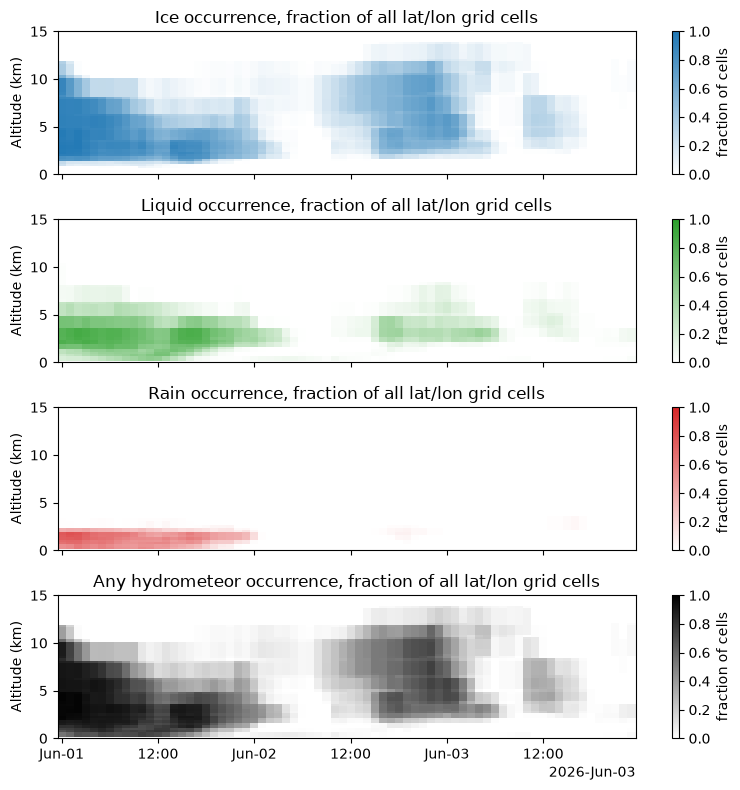

In [18]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

ok = c3.IWC.notnull()
names = {"Ice": ("ice_occ", "tab:blue"), "Liquid": ("liquid_occ", "tab:green"),
         "Rain": ("rain_occ", "tab:red"), "Any hydrometeor": ("hydrometeor_occ", "k")}

fig, axes = plt.subplots(4, 1, figsize=(8, 8), sharex=True, sharey=True)
for ax, (n, (v, color)) in zip(axes, names.items()):
    frac = c3[v].where(ok).mean(["latitude", "longitude"]) # fraction of grid cells with the hydrometeor, 0..1
    frac.plot.pcolormesh(x="time", y="alt", ax=ax, cmap=LinearSegmentedColormap.from_list("", ["white", color]),
                         vmin=0, vmax=1, cbar_kwargs={"label": "fraction of cells"})
    ax.set(title=f"{n} occurrence, fraction of all lat/lon grid cells", xlabel="", ylabel="Altitude (km)")
    ax.set_ylim([0, 15])

plt.tight_layout()
plt.show()

In [22]:
out_path = grib_path.with_name(f"c3dir_like_{grib_path.stem}.nc")
out_path

PosixPath('../data/era5/boston_subset/c3dir_like_era5_20260601_20260603_N45.5_W74_S39.5_E68.nc')

In [23]:
c3.to_netcdf(out_path)